# Customer Churn Prediction

Customer retention is essential for any live-service and subscription-based business models as this greatly impacts company revenue and growth. When a product or service fails to meet customer expectations or an alternative becomes more compelling, customers may discontinue their subscription service with the company, creating customer churn. The focus of this repository is the development and training of a machine learning algorithm that can predict if a customer will churn based off user usage data. The data used for model training is the Customer Churn Dataset found on Kaggle.com, uploaded by Kaggle user Muhammad Shahid Azeem. In this dataset there are over 500k rows of customer data usage with each record including features such as customer age, gender, tenure, usage frequency, support calls, payment delay, subscription type, contract length, total spend, and last interaction. The data also contains a churn label feature that indicates whether the customer has churned (1) or not (0). In this repository, the final model used is a Random Forest Classifier as this model outperformed all other models at the base level, with a CNN model being a close second. Various evaluation metrics highlights the model’s performance: for “not churn,” the model achieved high precision (0.99) but lower recall (0.86) and an F-score of 0.92; for “churn,” the model scored a precision of 0.90, a perfect recall (1.00), and an F-score of 0.94. Despite heavy data imbalance, the model is able to reliably predict customer churn and retention, that said, further fine-tuning and data balancing could possibly further enhance overall model performance and predictive capabilities.

# Business Understanding

For a business with a live service product or a subscription-based product, it often requires active consumer retention to maintain the product or service running. In order for a business to maintain consumer retention they often have to produce a product that will set them apart from any others that offer the same kind of service or product. In some cases, for whatever reason the offered product can fail to retain consumers leading to customer churn.

Customer churn refers to when customers discontinue their relationship or subscription with a company or service. It also represents the rate at which customers stop using a company's products or services within a specific period.
Understanding customer churn is crucial for businesses as this lets them identify patterns, factors, and indicators that contribute to customer attrition. Churn is an important business metric as it impacts revenue, and growth. By analyzing churn behavior and its associated features, companies can develop strategies to retain existing customers, improve customer satisfaction, and reduce customer turnover. Through the use of predictive machine learning models, it is possible to forecast and proactively address potential churn, allowing companies to take the necessary measures to minimize or even retain at risk consumers.

# Data Understanding

The data used for model training is the [Customer Churn Dataset](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset) found on [Kaggle.com](https://www.kaggle.com/), uploaded by Kaggle user [Muhammad Shahid Azeem](https://www.kaggle.com/muhammadshahidazeem). In this dataset we can find over 500k rows of customer data usage with each record including features such as age, gender, tenure, usage frequency, support calls, payment delay, subscription type, contract length, total spend, and last interaction. The data also contains a churn label that indicates whether the customer has churned (1) or not (0).

Upon first looks of the data we can tell the data is heavily imbalanced with "churn" having 55k+ more rows of data compared to it "not churn". The data also appears to be very clean with only 1 NaN row which seems to just be a filler row of some kind. As for the data types, the categorical features are the proper dtype, but the numerical features are a mixture of integer and float dtypes.

In [ ]:
# Install packages in Google Colab
# Cell output cleared as it only contains installation progress
!pip install tensorflow
!pip install keras
!pip install keras.preprocessing
!pip install scikeras[tensorflow]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Code to create kaggle path for data download
# Code taken from stackoverflow user fdsig
import json
import os
from pathlib import Path

# your api key
api_key = {
'username':"",
'key':""}

# uses pathlib Path
kaggle_path = Path('/root/.kaggle')
os.makedirs(kaggle_path, exist_ok=True)

# opens file and dumps python dict to json object
with open (kaggle_path/'kaggle.json', 'w') as handl:
    json.dump(api_key,handl)

os.chmod(kaggle_path/'kaggle.json', 600)

In [ ]:
# Downloading kaggle dataset
!kaggle datasets download -d muhammadshahidazeem/customer-churn-dataset

# Creating parent folder directory for data unzip
!unzip customer-churn-dataset.zip -d customer-churn-dataset

Dataset URL: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
License(s): GPL-2.0
100% 6.66M/6.66M [00:00<00:00, 111MB/s]

Archive:  customer-churn-dataset.zip
  inflating: customer-churn-dataset/customer_churn_dataset-testing-master.csv  
  inflating: customer-churn-dataset/customer_churn_dataset-training-master.csv  


In [ ]:
# Loading data
train_data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-training-master.csv')
test_data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-testing-master.csv')

In [ ]:
train_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
test_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
[train_data.info()], [test_data.info()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  D

([None], [None])

In [ ]:
train_data.isna().sum(), test_data.isna().sum()

(CustomerID           1
 Age                  1
 Gender               1
 Tenure               1
 Usage Frequency      1
 Support Calls        1
 Payment Delay        1
 Subscription Type    1
 Contract Length      1
 Total Spend          1
 Last Interaction     1
 Churn                1
 dtype: int64,
 CustomerID           0
 Age                  0
 Gender               0
 Tenure               0
 Usage Frequency      0
 Support Calls        0
 Payment Delay        0
 Subscription Type    0
 Contract Length      0
 Total Spend          0
 Last Interaction     0
 Churn                0
 dtype: int64)

In [ ]:
train_data['Churn'].value_counts()

,count
Churn,
1.0,249999
0.0,190833


In [ ]:
test_data['Churn'].value_counts()

,count
Churn,
0,33881
1,30493


## Data Preprocessing

Prior to preparing the data for model training I did some minor data cleaning as luckily this data is very clean and organized. First step I took for data preprocessing was to concat both the train data and test data into a single dataset as both these data sets are imbalanced and by combining both these sets it will help get a better data split when it comes to splitting between train and test data. After combining the datasets, I make a copy of the data to avoid any potential row change warnings and drop the single NaN row as well as reset the data’s index since I combined two datasets together. From there I lowercase the feature titles and replace any whitespaces with underscores, I lastly convert most of the numerical values to integer data type as all except the 'total spend' feature values are whole numbers, and by doing so I can keep the numerical data types uniform.

In [ ]:
# Combining test and train data
data = pd.concat([train_data, test_data], axis=0)
data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
64370,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
64371,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
64372,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [ ]:
# Making copy of our data
df = data.copy()

# Dropping single NaN row
df = df.dropna().reset_index(drop=True)
df[df['CustomerID'].isna()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [ ]:
# Lowercasing and replacing whitespace in columns
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [ ]:
# Converting non-monetary numbers to integer dtype
col_list = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']

for col in col_list:
  df[col] = df[col].astype('int64')

In [ ]:
df

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,2.0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3.0,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4.0,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5.0,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6.0,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
505201,64370.0,45,Female,33,12,6,21,Basic,Quarterly,947.0,14,1
505202,64371.0,37,Male,6,1,5,22,Standard,Annual,923.0,9,1
505203,64372.0,25,Male,39,14,8,30,Premium,Monthly,327.0,20,1
505204,64373.0,50,Female,18,19,7,22,Standard,Monthly,540.0,13,1


## Exploratory data Analysis

To understand the data a bit better and the way it is distributed, I did a little bit of Exploratory Data Analysis (EDA) with some of the features in the data.

The first plot is a box plot that shows how spread out the data is with payment delay and customer churn. From this plot we can see that customers with shorter delays on payment were less likely to churn, while those with a delay of 10+ days had a much larger chance of ending their service.

The second plot is a simple bar plot that shows us the age distribution in the data. From this plot we can see that the majority of customers are between the ages of 18 - 50 with the greater majority being between 40 - 50 years of age, and ages 51 - 65 being the minority age group. The third plot is a continuation of the second plot as this plot shows us age to churn ratio. From this plot we can see customers between the ages of 30 - 50 are less likely to end service, while those between the ages of 18 - 29 and 51 - 65 are more likely to churn.

The final plot shows the churn to no churn frequency amongst genders found in the dataset. This plot shows us that between male and female customers, female customers are much more likely to churn while male customers are less likely to churn.

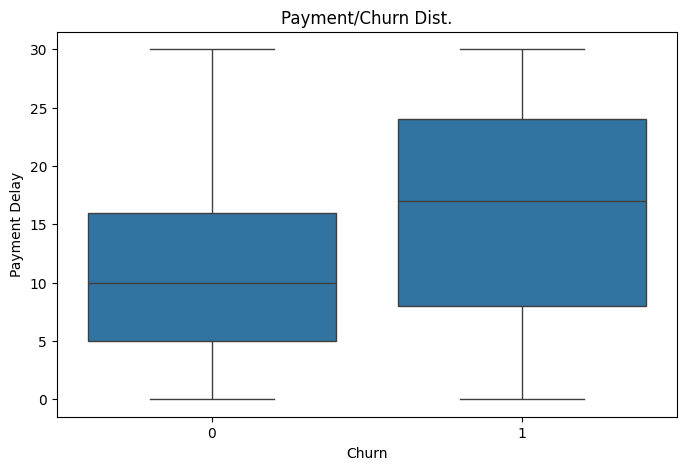

In [ ]:
# Payment Delay/Churn Distribution plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(df, x='churn', y= 'payment_delay')

ax.set_title('Payment/Churn Dist.')
ax.set_xlabel('Churn')
ax.set_ylabel('Payment Delay');

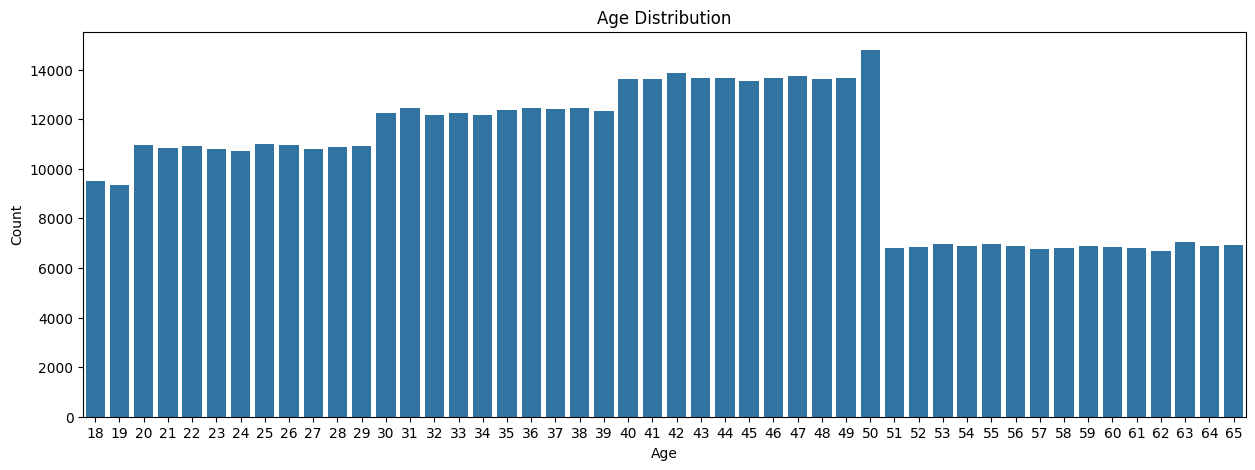

In [ ]:
# Age Distribution plot
age_dict_vc = dict(df['age'].value_counts())
age_values = list(age_dict_vc.values())
age_keys = list(age_dict_vc.keys())

fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(x=age_keys, y=age_values, ax=ax)

ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count');

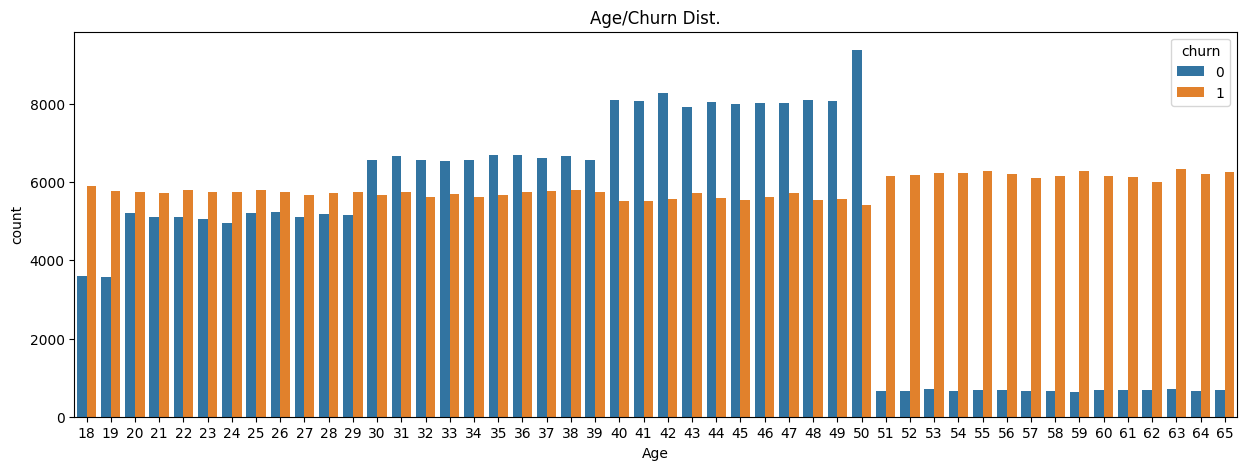

In [ ]:
# Age/Churn Distribution plot
fig, ax = plt.subplots(figsize=(15, 5))

sns.countplot(df, x='age', hue='churn')

ax.set_title('Age/Churn Dist.')
ax.set_xlabel('Age');

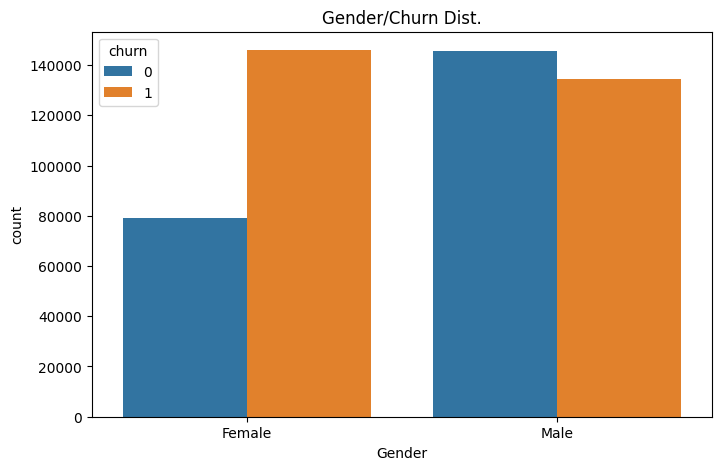

In [ ]:
# Gender/Churn Distribution plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(df, x='gender', hue='churn')

ax.set_title('Gender/Churn Dist.')
ax.set_xlabel('Gender');

# Data Preparation

To prepare the data I first set my X and y variables, for the X variable I kept all features except for the “churn” feature as this is our y variable, and “customerid” as this feature is a unique identifier and essentially holds no value. For the train and test split I split the data to be 80% as training data and 20% as test data, I also set the random state seed to 42 for consistent results for each run of the notebook. After the split I create copies of the training and testing sets of data to use for pipeline development. To finalize the data preparation, I use two functions from the Flatiron school to encode the categorical features found in the data and transforms a feature into multiple columns of 1s and 0s, I then create a function that concats these new features into our dataframe while dropping the old categorical feature columns.


In [ ]:
# Splitting data
X = df.drop(['customerid', 'churn'], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Creating copies for pipeline use
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()
X_test_copy = X_test.copy()
y_test_copy = y_test.copy()

In [ ]:
# Both encode_and_concat_feature_train, and encode_and_concat_feature taken from Flatiron School lecture
def encode_and_concat_feature_train(X_train, feature_name):
    """
    Helper function for transforming training data. It takes in the full X dataframe and
    feature name, makes a one-hot encoder, and returns the encoder as well as the dataframe
    with that feature transformed into multiple columns of 1s and 0s
    """
    # make a one-hot encoder and fit it to the training data
    ohe = OneHotEncoder(categories="auto", handle_unknown="ignore")
    single_feature_df = X_train[[feature_name]]
    ohe.fit(single_feature_df)

    # call helper function that actually encodes the feature and concats it
    X_train = encode_and_concat_feature(X_train, feature_name, ohe)

    return ohe, X_train

def encode_and_concat_feature(X, feature_name, ohe):
    """
    Helper function for transforming a feature into multiple columns of 1s and 0s. Used
    in both training and testing steps. It Takes in the full X dataframe, feature name,
    and encoder, and returns the dataframe with that feature transformed into multiple
    columns of 1s and 0s
    """
    # create new one-hot encoded df based on the feature
    single_feature_df = X[[feature_name]]
    feature_array = ohe.transform(single_feature_df).toarray()
    ohe_df = pd.DataFrame(feature_array, columns=ohe.categories_[0], index=X.index)

    # drop the old feature from X and concat the new one-hot encoded df
    X = X.drop(feature_name, axis=1)
    X = pd.concat([X, ohe_df], axis=1)

    return X

encoders = {}

# Onehotencode data
def encode_data(data, cat_features):
    """
    Function for onehotencoding categorical features train or test data and
    appending to dataframe.
    """
    for feature in cat_features:
        ohe, data = encode_and_concat_feature_train(data, feature)
        encoders[feature] = ohe

    return data

In [ ]:
# Encoding train and test data categorical features
categorical_features = ['gender', 'subscription_type', 'contract_length']

X_train = encode_data(X_train, categorical_features)
X_test = encode_data(X_test, categorical_features)

X_train

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,Female,Male,Basic,Premium,Standard,Annual,Monthly,Quarterly
166878,48,57,8,2,11,885.00,16,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
347476,33,43,13,0,1,684.44,23,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
254092,37,26,18,1,5,778.02,6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
146324,27,44,4,4,13,502.00,8,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
300199,35,56,2,0,1,603.26,27,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,41,44,18,2,13,717.39,3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
365838,45,44,14,3,13,995.38,8,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
131932,37,9,4,10,12,979.00,8,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
146867,33,27,5,10,20,824.00,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


# Modeling

For the modeling process I created a total of 4 models 2 supervised, 2 deep learning, to gauge which model would work best with the data at a base level and later fine tune. The two supervised learning models I used were Logistic Regression and Random Forest Classifier, I went with these two supervised learning models as logistic regression models work well in predicting binary outcomes, in this case "churn" or "no churn". I also chose a Random Forest Classifier as a test model as this machine learning model is fairly accurate with their prediction, and so are often used when it comes to churn predictions.

For the deep learning base models, I went with a Sequential model as well as a Convolutional Neural Network (CNN) model. I chose a Sequential model as same as the random forest; these kinds of models do well with data that can be used for forecasting customer retention. A Convolutional Neural Network can be seen as a weird choice for a test model as these kinds of models are primarily meant for image recognition. That being said CNN models are also good at recognizing patterns in data early on as well as complex patterns in the deeper layers.

Ultimately, the final model used was Random Forest Classifier as this model outperformed all other models at the base level, with the CNN model being a close second. To fine tune the random forest model I used GridSearchCV to find the best parameters from a range of possible settings, and the best parameters for the rf classifier were a gini criterion with no max depth, balanced subsampling, 1 minimum samples per leaf, and 5 for minimum samples before a split.

Please note the Gridsearch process has been commented out as it takes more than 2 hours to run even with Google Colabs Pro+ resource privileges.

### Base Logistic Regression

In [ ]:
# Scaling data
standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)

In [ ]:
# Creating base logistic regression model
base_lr = LogisticRegression(random_state=42)

# Fitting data to base model
base_lr.fit(X_train_scaled, y_train)

# cross val score
base_lr_cv = cross_val_score(base_lr, X_train_scaled, y_train)
base_lr_cv

array([0.84914577, 0.84952928, 0.84912103, 0.84850247, 0.84970061])

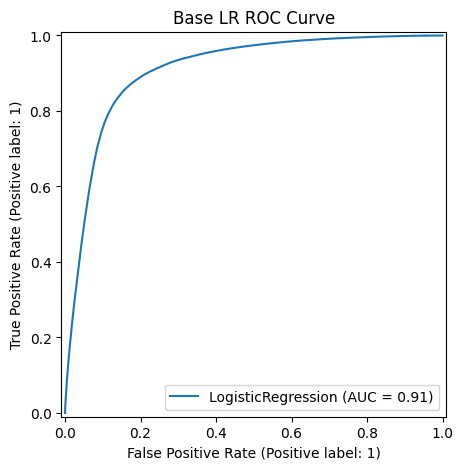

In [ ]:
# ROC Curve plot
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(base_lr, X_train_scaled, y_train, ax=ax)

ax.set_title('Base LR ROC Curve');

### Base Random Forest Classifier

In [ ]:
# Instantiate random forest classifier
base_rf_clf = RandomForestClassifier(random_state=42, max_samples=20000, max_depth=10)

# Fitting data to model
base_rf_clf.fit(X_train, y_train)

# Models cross validation scores
base_rf_clf_cv = cross_val_score(base_rf_clf, X_train, y_train)
base_rf_clf_cv

array([0.92636671, 0.92821001, 0.92858115, 0.9282595 , 0.92865449])

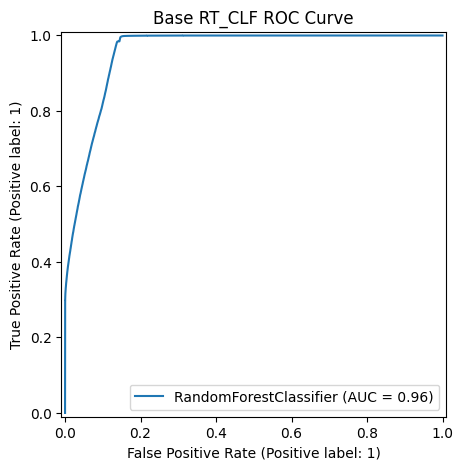

In [ ]:
# ROC Curve plot
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(base_rf_clf, X_train, y_train, ax=ax)

ax.set_title('Base RT_CLF ROC Curve');

### Deep Learning Models

In [ ]:
# Function to quickly plot model results
def plot_results(model_results):
    """
    This function will take in the results of a model and plot the loss and accuracy of the model.

    Args:
    model_results (list): the results of the model in [] brackets.
    """
    for results in model_results:
        train_loss = results.history['loss']
        train_acc = results.history['accuracy']
        val_loss = results.history['val_loss']
        val_acc = results.history['val_accuracy']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        sns.lineplot(x=results.epoch, y=train_loss, ax=ax1, label='train_loss')
        sns.lineplot(x=results.epoch, y=train_acc, ax=ax2, label='train_accuracy')

        sns.lineplot(x=results.epoch, y=val_loss, ax=ax1, label='val_loss')
        sns.lineplot(x=results.epoch, y=val_acc, ax=ax2, label='val_accuracy')
        ax1.set_title('Loss')
        ax2.set_title('Accuracy')
        ax1.legend();

In [ ]:
# Creating validation data
X_train_dlm, val_data, y_train_dlm, val_labels = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
# Base sequential model
base_seq_model = Sequential([
                             layers.Input(shape=(X_train_dlm.shape[1],)),
                             layers.Dense(64, activation='relu'),
                             layers.Dense(32, activation='relu'),
                             layers.Dense(16, activation='relu'),
                             layers.Dense(1, activation='sigmoid')
                         ])

base_seq_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Fitting train data to model
base_seq_model_results = base_seq_model.fit(X_train_dlm, y_train_dlm,
                                            epochs=20,
                                            batch_size=1000,
                                            validation_data=(val_data, val_labels))

Epoch 1/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7232 - loss: 1.6546 - val_accuracy: 0.8204 - val_loss: 0.4263
Epoch 2/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8407 - loss: 0.3969 - val_accuracy: 0.8522 - val_loss: 0.3798
Epoch 3/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8570 - loss: 0.3681 - val_accuracy: 0.8626 - val_loss: 0.3576
Epoch 4/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8648 - loss: 0.3524 - val_accuracy: 0.8731 - val_loss: 0.3416
Epoch 5/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8724 - loss: 0.3397 - val_accuracy: 0.8795 - val_loss: 0.3315
Epoch 6/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8763 - loss: 0.3332 - val_accuracy: 0.8635 - val_loss: 0.3558
Epoch 7/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8786 - loss: 0.3298 - val_accuracy: 0.8765 - val_loss: 0.3300
Epoch 8/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8820 - loss: 0.3240 - val_accuracy: 

In [ ]:
# Test data eval
base_seq_model.evaluate(X_test, y_test)

3158/3158 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8947 - loss: 0.2952


[0.29524561762809753, 0.8947071433067322]

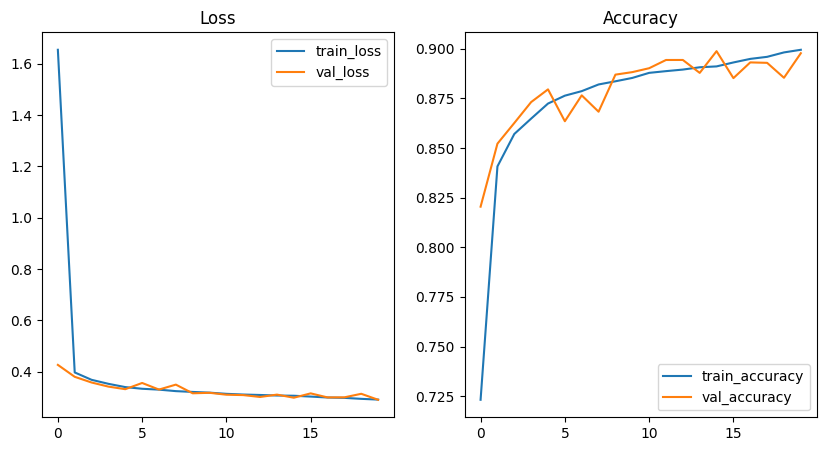

In [ ]:
# Plotting model loss and accuracy
plot_results([base_seq_model_results])

In [ ]:
# Base CNN model
base_cnn_model = Sequential([
                             layers.Input(shape=(X_train_dlm.shape[1], 1)),
                             layers.Conv1D(32, 2, activation='relu'),
                             layers.MaxPooling1D(),

                             layers.Conv1D(64, 2, activation='relu'),
                             layers.MaxPooling1D(),

                             layers.Flatten(),
                             layers.Dense(64, activation='relu'),
                             layers.Dense(32, activation='relu'),
                             layers.Dense(16, activation='relu'),
                             layers.Dense(1, activation='sigmoid')
])

base_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Fitting train data to model
base_cnn_model_results = base_cnn_model.fit(X_train_dlm, y_train_dlm,
                                            epochs=20,
                                            batch_size=1000,
                                            validation_data=(val_data, val_labels))

Epoch 1/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7547 - loss: 0.5306 - val_accuracy: 0.8083 - val_loss: 0.4374
Epoch 2/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8156 - loss: 0.4251 - val_accuracy: 0.8291 - val_loss: 0.4050
Epoch 3/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8245 - loss: 0.4116 - val_accuracy: 0.8336 - val_loss: 0.3964
Epoch 4/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.3961 - val_accuracy: 0.8452 - val_loss: 0.3801
Epoch 5/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8456 - loss: 0.3790 - val_accuracy: 0.8337 - val_loss: 0.4014
Epoch 6/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8517 - loss: 0.3686 - val_accuracy: 0.8575 - val_loss: 0.3641
Epoch 7/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8613 - loss: 0.3527 - val_accuracy: 0.8668 - val_loss: 0.3409
Epoch 8/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8696 - loss: 0.3392 - val_accuracy: 0

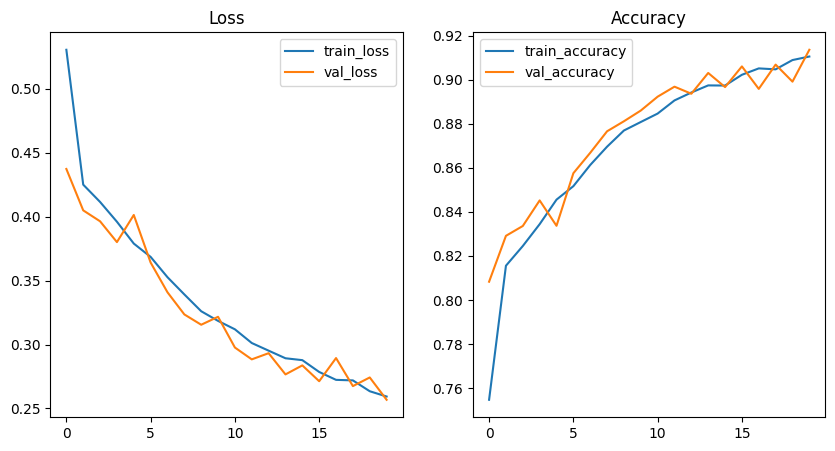

In [ ]:
# Plotting model loss and accuracy
plot_results([base_cnn_model_results])

In [ ]:
# Test data eval
base_cnn_model.evaluate(X_test, y_test)

3158/3158 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9110 - loss: 0.2602


[0.26020389795303345, 0.9109677076339722]

### Random Forest Grid Search

In [ ]:
#rf_clf = RandomForestClassifier(random_state=42, max_samples=20000)

In [ ]:
#rf_param_grid = {
#    'criterion': ['gini', 'entropy', 'log_loss'],
#    'max_depth': [None, 2, 3, 4, 5, 6],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 3, 4, 5, 6],
#    'class_weight': ['balanced', 'balanced_subsample']
#}


In [ ]:
#rf_grid_search = GridSearchCV(rf_clf, rf_param_grid, cv=5, n_jobs=2)

In [ ]:
# Take a little over 2hours to run
#rf_grid_search.fit(X_train, y_train)

In [ ]:
#rf_grid_search.best_params_

### Final Model Random Forest Classifier

In [ ]:
# Takes about 4min to run
# Instantiate random forest classifier
rf_clf_final = RandomForestClassifier(random_state=42, class_weight='balanced_subsample', criterion='gini', min_samples_leaf=1, min_samples_split=5)

# Fitting train data to model
rf_clf_final.fit(X_train, y_train_copy)

# Getting validation scores
rf_clf_final_cv = cross_val_score(rf_clf_final, X_train, y_train)
rf_clf_final_cv

array([0.93466777, 0.93480385, 0.93531107, 0.93543479, 0.93637421])

# Evaluation

The final model performed fairly well overall, but it does appear to struggle a bit when it comes to predicting if a customer is "not churn". This is **most likely due to the heavy imbalance** in the data creating some **model bias**, or it is possible that some of the "not churn" rows of data have very similar pattern to the "churn" classification, but this seems unlikely.

For the model’s classification metrics, it scored a **precision of 0.99, recall of 0.86, and an f-score of 0.92** when it came to predicting "not churn". For predicting customer "churn" the model scored a **precision of 0.90, a recall of 1.00, and an f-score 0.94**. From this report we can see that while the model may be precise with its "not churn" prediction, it does **struggle to recall** what it learned from this kind of data. For its customer "churn" predictions on the other hand, the model has a **lower precision rate** but it is able to recall all that it has learned from this kind of data.

By using a confusion matrix, we are able to get a visual representation of the classification scores as well as how the model did with its predictions. For "not churn" the model was able to **correctly predict over 38k customer** status with 6507 the model believing were "churn" when in fact were not. For "churn" the model did much better with **over 55k correct predictions** and only 205 misclassified predictions.

In [ ]:
# Setting final model for evaluation
final_model = rf_clf_final

# Getting cross val scores for test data
final_model_cv = cross_val_score(final_model, X_test, y_test)
final_model_cv

array([0.92943738, 0.93210946, 0.92799881, 0.93121536, 0.93200713])

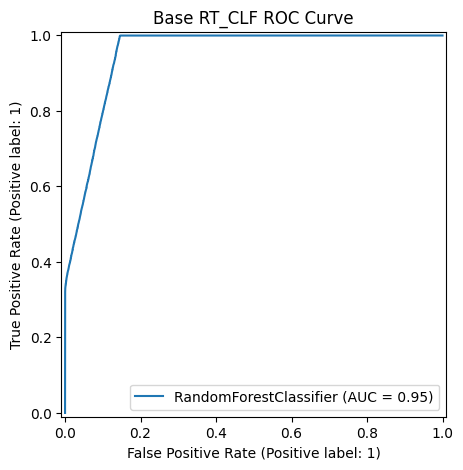

In [ ]:
# ROC Curve plot
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=ax)

ax.set_title('Base RT_CLF ROC Curve');

In [ ]:
# Getting model test data predictions
y_pred = final_model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred.round()))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92     44981
           1       0.90      1.00      0.94     56061

    accuracy                           0.93    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



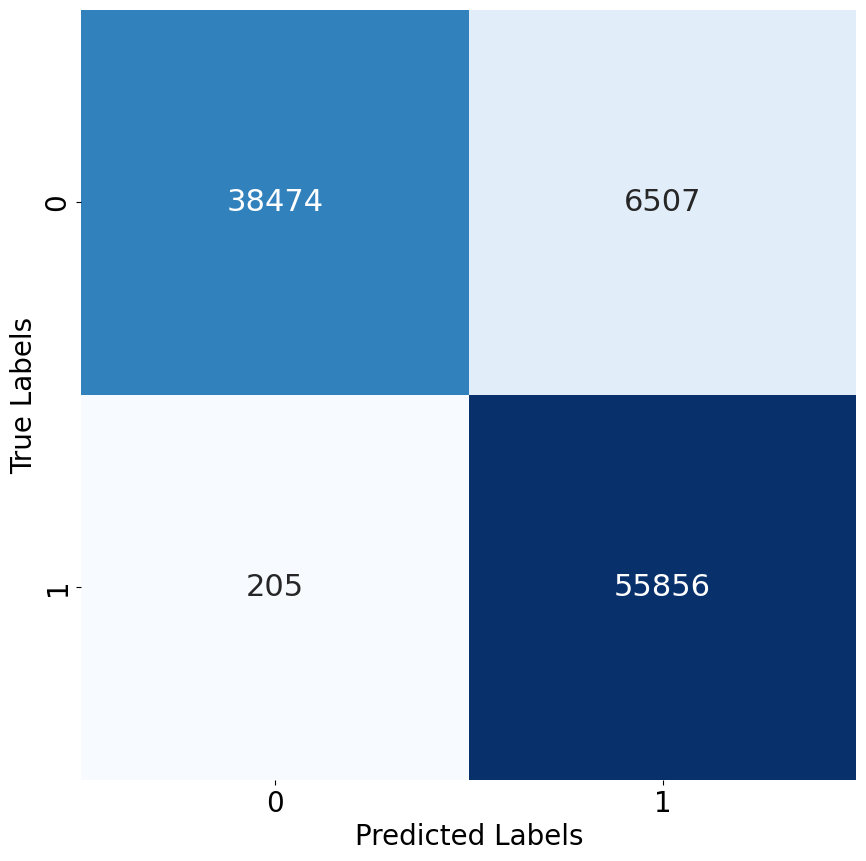

In [ ]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))

cm = confusion_matrix(y_test, y_pred.round())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size' : 22}, cbar=False)

ax.tick_params(axis='both', labelsize=20)
ax.set_xlabel('Predicted Labels', fontsize=20)
ax.set_ylabel('True Labels', fontsize=20);

## Pipeline

In [ ]:
# Recreating numerical features to include 'total_spend'
numerical_features = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'total_spend', 'last_interaction']

In [ ]:
# Pipeline to encode categorical data
cate_pipe = Pipeline([
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline to scale numerical data
num_pipe = Pipeline([
    ('scale', StandardScaler())
])

# Combining pipelines
preprocessor = ColumnTransformer([
    ('cat_pipe', cate_pipe, categorical_features),
    ('num_pipe', num_pipe, numerical_features),
])

In [ ]:
# Creating classifier pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced_subsample', criterion='gini', min_samples_leaf=1, min_samples_split=5))
])

In [ ]:
# Fitting pipeline to training data
pipe.fit(X_train_copy, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat_pipe',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'subscription_type',
                                                   'contract_length']),
                                                 ('num_pipe',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'tenure',
                                                   'usage_frequency',
                                                   'support_calls',
                                                   'payment_delay',
                                                   'total_spend',
                                                   'last_interaction'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_split=5,
                                        random_state=42))])

In [ ]:
# Pipeline score with test data
pipe.score(X_test_copy, y_test)

0.9336414560281863

In [ ]:
# Getting test data predictions
y_pred_pipe = pipe.predict(X_test_copy)

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92     44981
           1       0.90      1.00      0.94     56061

    accuracy                           0.93    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.93      0.93    101042



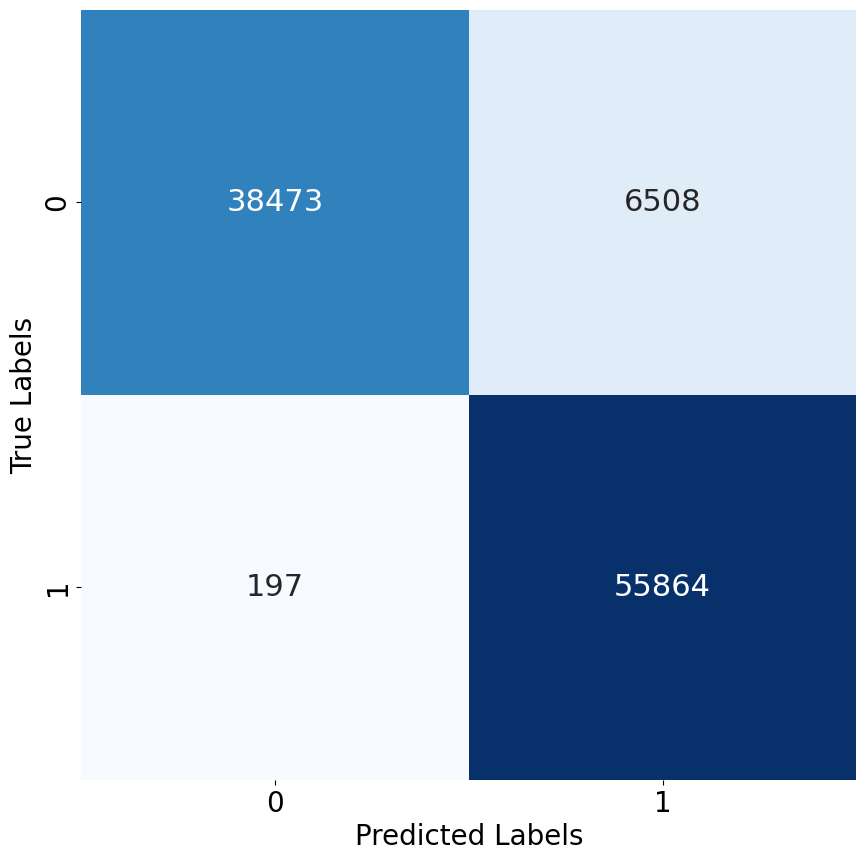

In [ ]:
# Plotting Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))

cm = confusion_matrix(y_test, y_pred_pipe)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size' : 22}, cbar=False)

ax.tick_params(axis='both', labelsize=20)
ax.set_xlabel('Predicted Labels', fontsize=20)
ax.set_ylabel('True Labels', fontsize=20);

## Limitations

The biggest limitation for this model is the heavy imbalance in the data with **over 55k** more rows of data in favor of the "churn" classification as compared to "not churn".

A second limitation I encountered was with the Random Forest Classifier and it's **limited parameter settings** when it comes to dealing with the imbalanced data set and the more balance I tried to do, the model would get lower scores overall.

## Next Steps

A potential next step would be to **incorporate SMOTE** into the data to create enough fake data to balance out the data set, but the issue with using SMOTE is that it would be **making up the data** and in a real world situation using **real customer data would be much more beneficial**.

A second next step would be to **fine-tune the second best model** in this notebook which is the CNN model, compared to the random forest model, the **CNN model underperformed by about 2 points** in the validation scores, so with a difference that low it would be something **worth looking into for better results**.

# Conclusion

Overall, the model performed very well despite the heavy class imbalance found in the data. The model is able to correctly predict the majority of the data used during testing and with deeper fine-tuning and data balancing, it may be possible to yield better overall results lowering the model’s false negative results.